# 0. Setup e imports

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

DATA_PATH    = "../data/raw/transaction_data.csv"
PRODUCT_PATH = "../data/raw/product.csv"
GRAPH_DIR    = "../outputs/graphs"

## 1. Raw data inspection

In [2]:
raw = pd.read_csv(DATA_PATH, dtype={"BASKET_ID": int, "PRODUCT_ID": int, "DAY": int})
print(f"Shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
print(f"Day range: {raw['DAY'].min()} → {raw['DAY'].max()}  ({raw['DAY'].nunique()} unique days)")
print(f"Unique baskets: {raw['BASKET_ID'].nunique():,}")
print(f"Unique products: {raw['PRODUCT_ID'].nunique():,}")
print(f"\nMissing values:\n{raw.isnull().sum()[raw.isnull().sum() > 0]}")
raw.head()

Shape: (2595732, 12)
Columns: ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']
Day range: 1 → 711  (711 unique days)
Unique baskets: 276,484
Unique products: 92,339

Missing values:
Series([], dtype: int64)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


Basket size stats (raw):
count    276484.000000
mean          9.388362
std          12.283792
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max         168.000000
Name: PRODUCT_ID, dtype: float64

Single-item baskets: 60,045  (21.7%)


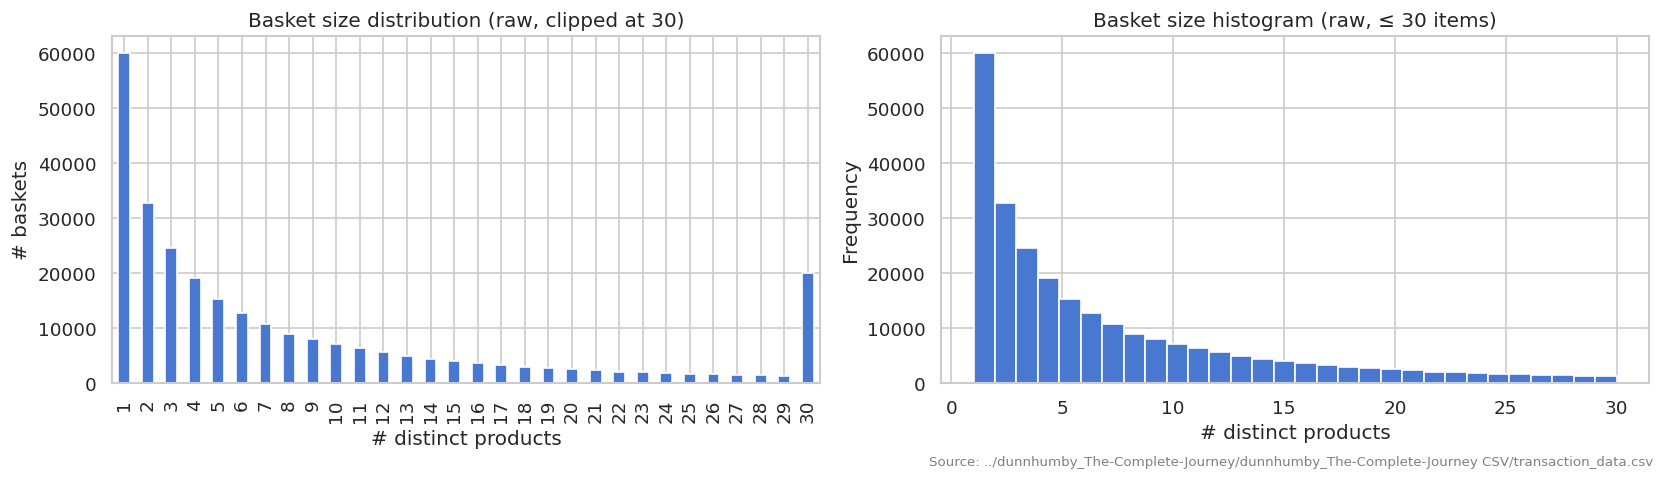

In [3]:
# Basket size distribution (before filtering)
basket_sizes_raw = raw.groupby("BASKET_ID")["PRODUCT_ID"].nunique()
print(f"Basket size stats (raw):\n{basket_sizes_raw.describe()}\n")
print(f"Single-item baskets: {(basket_sizes_raw == 1).sum():,}  ({100*(basket_sizes_raw==1).mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
basket_sizes_raw.clip(upper=30).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Basket size distribution (raw, clipped at 30)")
axes[0].set_xlabel("# distinct products")
axes[0].set_ylabel("# baskets")

basket_sizes_raw[basket_sizes_raw <= 30].plot(kind="hist", bins=30, ax=axes[1])
axes[1].set_title("Basket size histogram (raw, ≤ 30 items)")
axes[1].set_xlabel("# distinct products")
fig.text(0.99, 0.01, f"Source: {DATA_PATH}", ha="right", fontsize=8, color="gray")
plt.tight_layout()

AttributeError: 'Index' object has no attribute 'quantile'

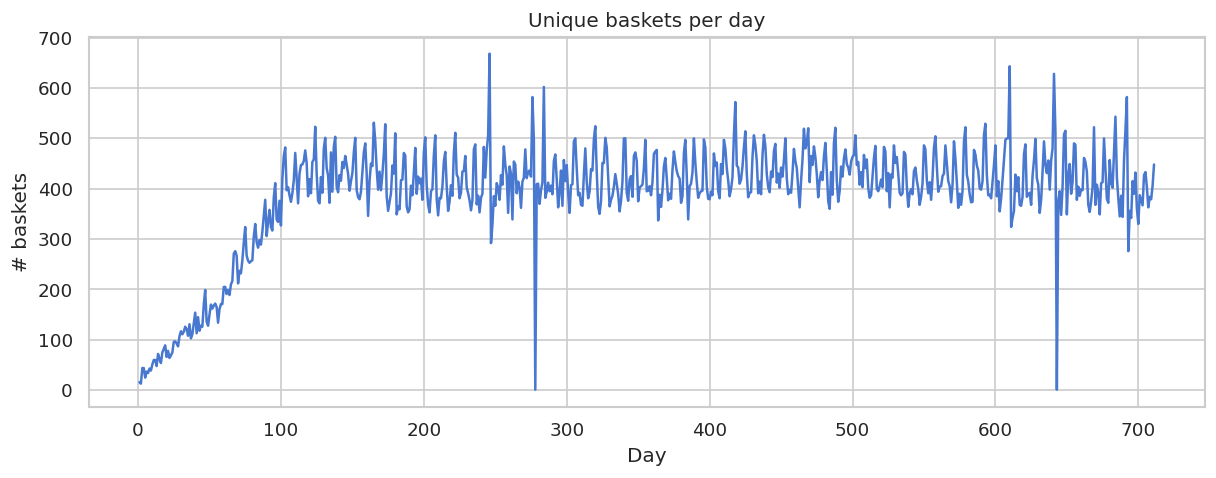

In [4]:
# Transactions per day — check for temporal coverage gaps
txn_per_day = raw.groupby("DAY")["BASKET_ID"].nunique()
fig, ax = plt.subplots(figsize=(12, 4))
txn_per_day.plot(ax=ax)
ax.set_title("Unique baskets per day")
ax.set_xlabel("Day")
ax.set_ylabel("# baskets")
ax.axvline(txn_per_day.index.quantile(0.8), color="red", linestyle="--", label="80% cutoff (train/test split)")
ax.legend()
plt.tight_layout()

## 2. Preprocessing pipeline output

In [5]:
from src.preprocessing.loader import load_transactions
from src.preprocessing.cleaner import clean_transactions
from src.preprocessing.splitter import split_by_day

df = load_transactions(DATA_PATH, min_basket_size=2, product_csv_path=PRODUCT_PATH)
df, product_index, product_meta = clean_transactions(df, min_support=50)
train_baskets, test_baskets = split_by_day(df, train_fraction=0.8)

n_products = len(product_index)
print(f"Vocabulary size (products after filtering): {n_products:,}")
print(f"Train baskets: {len(train_baskets):,}")
print(f"Test  baskets: {len(test_baskets):,}")
print(f"\nproduct_meta columns: {list(product_meta.columns)}")
product_meta.head()

Vocabulary size (products after filtering): 10,246
Train baskets: 167,036
Test  baskets: 40,087

product_meta columns: ['product_id', 'commodity_desc', 'sub_commodity_desc', 'department', 'brand']


,product_id,commodity_desc,sub_commodity_desc,department,brand
product_idx,,,,,
0,201704,TROPICAL FRUIT,BANANAS,PRODUCE,National
1,818980,BEANS - CANNED GLASS & MW,PREPARED BEANS - BAKED W/PORK,GROCERY,National
2,818981,COLD CEREAL,ALL FAMILY CEREAL,GROCERY,National
3,819063,PASTA SAUCE,MAINSTREAM,GROCERY,National
4,819112,CANNED JUICES,TOMATO JUICE (OVER 50% JCE),GROCERY,National


In [6]:
# Sanity checks: no leakage — train and test baskets share no basket_id
train_ids = df[df["basket_id"].isin(
    df.groupby("basket_id")["day"].min().pipe(lambda s: s[s <= s.quantile(0.8)]).index
)]["basket_id"].unique()
test_ids = df[~df["basket_id"].isin(train_ids)]["basket_id"].unique()
overlap = set(train_ids) & set(test_ids)
assert len(overlap) == 0, f"Leakage detected: {len(overlap)} baskets in both splits"
print("No basket ID overlap between train and test.")

# Basket size distribution after cleaning
train_sizes = [len(b) for b in train_baskets]
test_sizes  = [len(b) for b in test_baskets]
print(f"\nTrain basket size — mean: {np.mean(train_sizes):.2f}, median: {np.median(train_sizes):.0f}, max: {max(train_sizes)}")
print(f"Test  basket size — mean: {np.mean(test_sizes):.2f},  median: {np.median(test_sizes):.0f},  max: {max(test_sizes)}")

No basket ID overlap between train and test.

Train basket size — mean: 9.62, median: 6, max: 142
Test  basket size — mean: 9.98,  median: 6,  max: 128


Top 10 most frequent products:
  TROPICAL FRUIT                            29,643 baskets
  FLUID MILK PRODUCTS                       14,129 baskets
  FLUID MILK PRODUCTS                       12,349 baskets
  FLUID MILK PRODUCTS                       9,589 baskets
  EGGS                                      9,064 baskets
  FLUID MILK PRODUCTS                       7,182 baskets
  BAKED BREAD/BUNS/ROLLS                    6,851 baskets
  BAKED BREAD/BUNS/ROLLS                    6,102 baskets
  BAKED BREAD/BUNS/ROLLS                    5,458 baskets
  EGGS                                      5,301 baskets


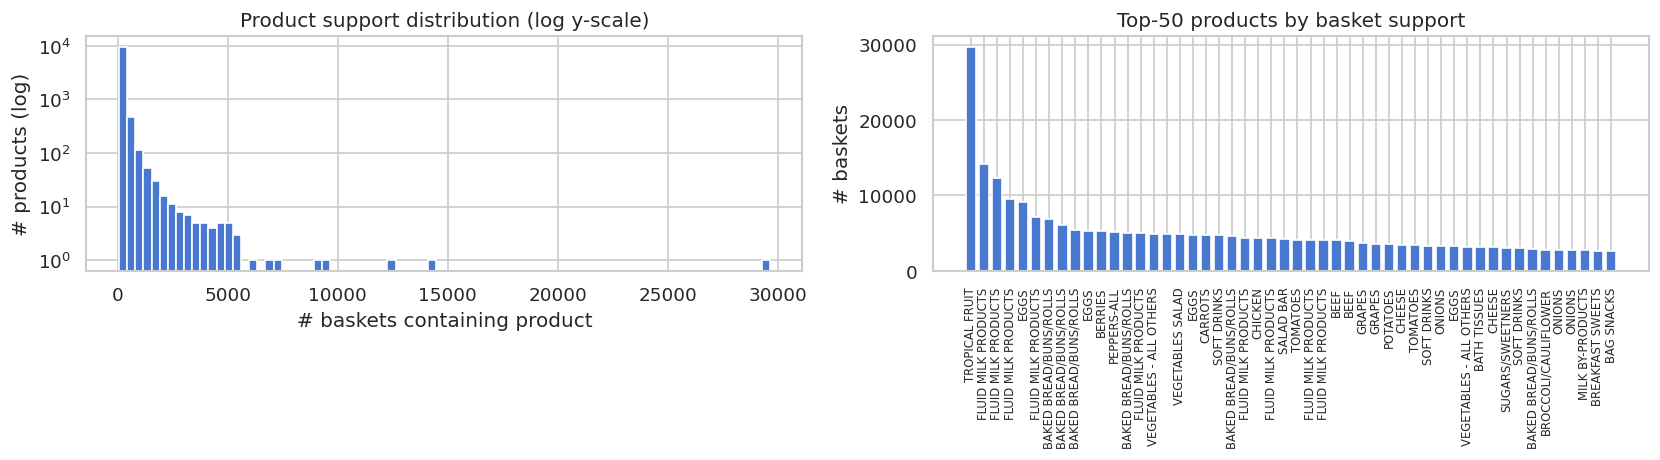

In [7]:
# Product support distribution (how many baskets each product appears in)
product_support = df.groupby("product_id")["basket_id"].nunique().sort_values(ascending=False)

# Enrich with product names for display
idx_to_pid = product_meta["product_id"].to_dict()          # product_idx → product_id
pid_to_name = (
    product_meta.reset_index()
    .set_index("product_id")["commodity_desc"]
    .to_dict()
)
top50_support = product_support.head(50)
top50_labels = [pid_to_name.get(pid, str(pid)) for pid in top50_support.index]

print(f"Top 10 most frequent products:")
for pid, count in product_support.head(10).items():
    print(f"  {pid_to_name.get(pid, pid):40s}  {count:,} baskets")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
product_support.plot(kind="hist", bins=80, log=True, ax=axes[0])
axes[0].set_title("Product support distribution (log y-scale)")
axes[0].set_xlabel("# baskets containing product")
axes[0].set_ylabel("# products (log)")

axes[1].bar(range(len(top50_support)), top50_support.values)
axes[1].set_xticks(range(len(top50_support)))
axes[1].set_xticklabels(top50_labels, rotation=90, fontsize=7)
axes[1].set_title("Top-50 products by basket support")
axes[1].set_ylabel("# baskets")
plt.tight_layout()

## 3. Co-occurrence matrix inspection

In [8]:
from src.graph.cooccurrence import build_cooccurrence

cooc = build_cooccurrence(train_baskets, n_products)

print(f"Co-occurrence matrix shape: {cooc.C.shape}")
print(f"Nonzero entries: {cooc.C.nnz:,}")
print(f"Density: {cooc.C.nnz / (cooc.n_products ** 2):.6f}")
print(f"Total baskets (N): {cooc.N:,}")
print(f"Max co-occurrence count: {cooc.C.data.max()}")
print(f"N_items range: [{cooc.N_items.min()}, {cooc.N_items.max()}]  (sanity: should be ≥ min_support=50)")

Co-occurrence matrix shape: (10246, 10246)
Nonzero entries: 16,855,056
Density: 0.160554
Total baskets (N): 167,036
Max co-occurrence count: 2686
N_items range: [0, 23811]  (sanity: should be ≥ min_support=50)



Pairs with ≥ 5 co-occurrences: 516,938
Pairs with ≥ 10 co-occurrences: 159,471
Pairs with ≥ 50 co-occurrences: 9,895


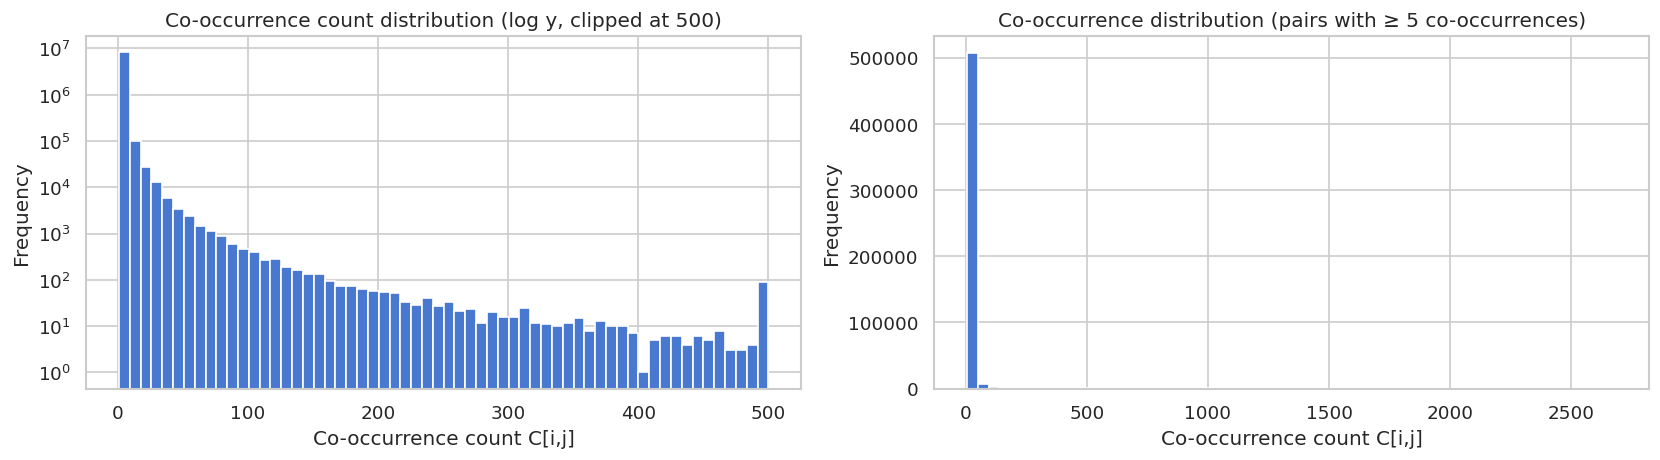

In [9]:
# Co-occurrence count distribution
cooc_coo = cooc.C.tocoo()
cooc_upper = cooc_coo.data[cooc_coo.row < cooc_coo.col]  # upper triangle only (avoid double-counting)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(cooc_upper).clip(upper=500).plot(kind="hist", bins=60, log=True, ax=axes[0])
axes[0].set_title("Co-occurrence count distribution (log y, clipped at 500)")
axes[0].set_xlabel("Co-occurrence count C[i,j]")

pd.Series(cooc_upper[cooc_upper >= 5]).plot(kind="hist", bins=60, ax=axes[1])
axes[1].set_title("Co-occurrence distribution (pairs with ≥ 5 co-occurrences)")
axes[1].set_xlabel("Co-occurrence count C[i,j]")
plt.tight_layout()

print(f"\nPairs with ≥ 5 co-occurrences: {(cooc_upper >= 5).sum():,}")
print(f"Pairs with ≥ 10 co-occurrences: {(cooc_upper >= 10).sum():,}")
print(f"Pairs with ≥ 50 co-occurrences: {(cooc_upper >= 50).sum():,}")

## 4. Lift matrix inspection

In [10]:
from src.graph.lift import compute_lift

lift_matrix = compute_lift(cooc, min_lift=1.0, min_cooccurrence=5)
lift_coo = lift_matrix.tocoo()

print(f"Lift matrix nonzero entries: {lift_matrix.nnz:,}")
print(f"Lift range: [{lift_coo.data.min():.4f}, {lift_coo.data.max():.4f}]")
print(f"Lift mean:  {lift_coo.data.mean():.4f}")
print(f"Lift median: {np.median(lift_coo.data):.4f}")

# Pairs surviving different lift thresholds
for thresh in [1.0, 1.5, 2.0, 3.0, 5.0]:
    n = (lift_coo.data > thresh).sum()
    print(f"  lift > {thresh}: {n:,} pairs")

Lift matrix nonzero entries: 1,012,432
Lift range: [1.0000, 5533.2836]
Lift mean:  16.4907
Lift median: 4.0162
  lift > 1.0: 1,012,432 pairs
  lift > 1.5: 952,826 pairs
  lift > 2.0: 858,414 pairs
  lift > 3.0: 658,488 pairs
  lift > 5.0: 405,470 pairs


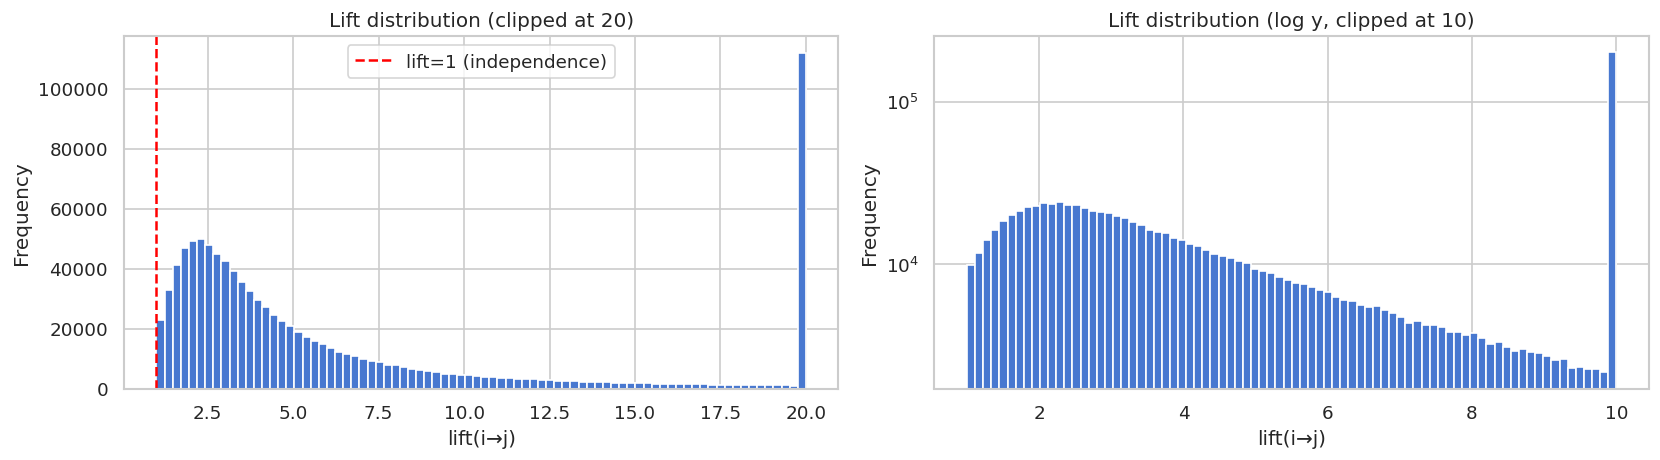

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pd.Series(lift_coo.data).clip(upper=20).plot(kind="hist", bins=80, ax=axes[0])
axes[0].set_title("Lift distribution (clipped at 20)")
axes[0].set_xlabel("lift(i→j)")
axes[0].axvline(1.0, color="red", linestyle="--", label="lift=1 (independence)")
axes[0].legend()

pd.Series(lift_coo.data).clip(upper=10).plot(kind="hist", bins=80, log=True, ax=axes[1])
axes[1].set_title("Lift distribution (log y, clipped at 10)")
axes[1].set_xlabel("lift(i→j)")
plt.tight_layout()

## 5. Graph inspection

In [12]:
from src.graph.builder import load_graph

G = load_graph(GRAPH_DIR, fmt="graphml")

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Directed edges: {G.number_of_edges():,}")
print(f"Is directed: {G.is_directed()}")

# Check weight preservation after round-trip
sample_edge = list(G.edges(data=True))[0]
i, j, attrs = sample_edge
print(f"\nSample edge: {i} → {j}  weight={attrs['weight']:.6f}")
assert isinstance(attrs["weight"], float), "Weight should be float after loading"
print("Weight type check passed.")

Nodes: 10,157
Directed edges: 1,012,432
Is directed: True

Sample edge: 1 → 34  weight=31.481775
Weight type check passed.


In-degree  — mean: 99.7, median: 30, max: 9315
Out-degree — mean: 99.7, median: 30, max: 9315
Isolated nodes (degree 0): 0


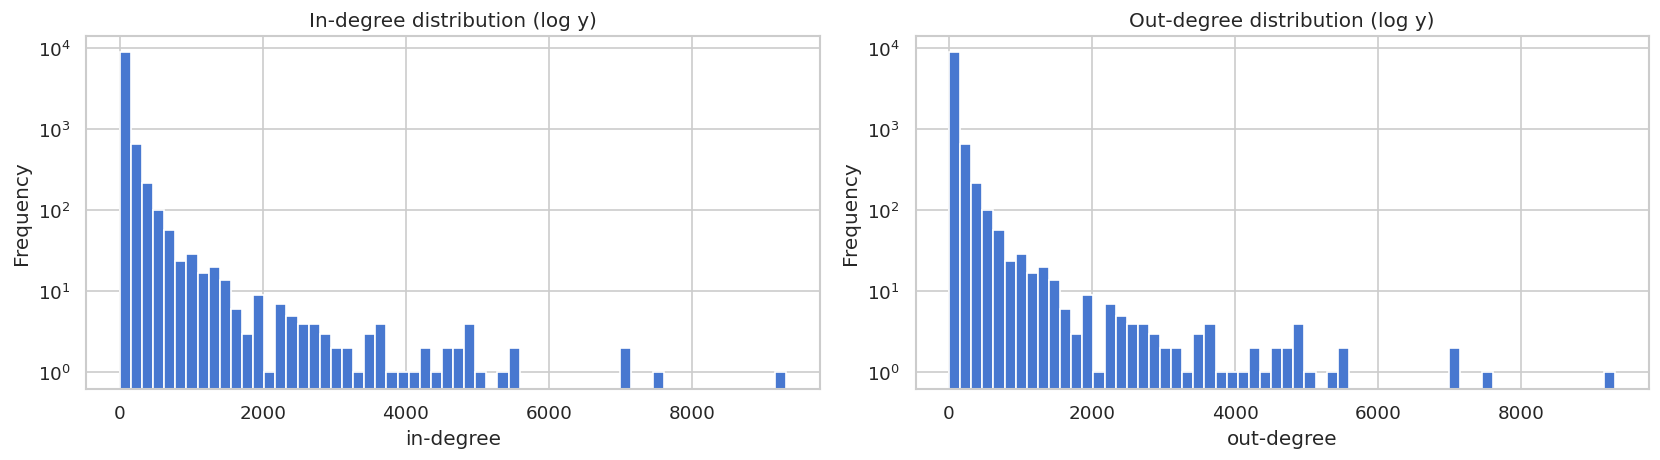

In [13]:
# Degree distribution
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print(f"In-degree  — mean: {np.mean(in_degrees):.1f}, median: {np.median(in_degrees):.0f}, max: {max(in_degrees)}")
print(f"Out-degree — mean: {np.mean(out_degrees):.1f}, median: {np.median(out_degrees):.0f}, max: {max(out_degrees)}")
print(f"Isolated nodes (degree 0): {sum(1 for d in in_degrees if d == 0)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(in_degrees).plot(kind="hist", bins=60, log=True, ax=axes[0])
axes[0].set_title("In-degree distribution (log y)")
axes[0].set_xlabel("in-degree")

pd.Series(out_degrees).plot(kind="hist", bins=60, log=True, ax=axes[1])
axes[1].set_title("Out-degree distribution (log y)")
axes[1].set_xlabel("out-degree")
plt.tight_layout()

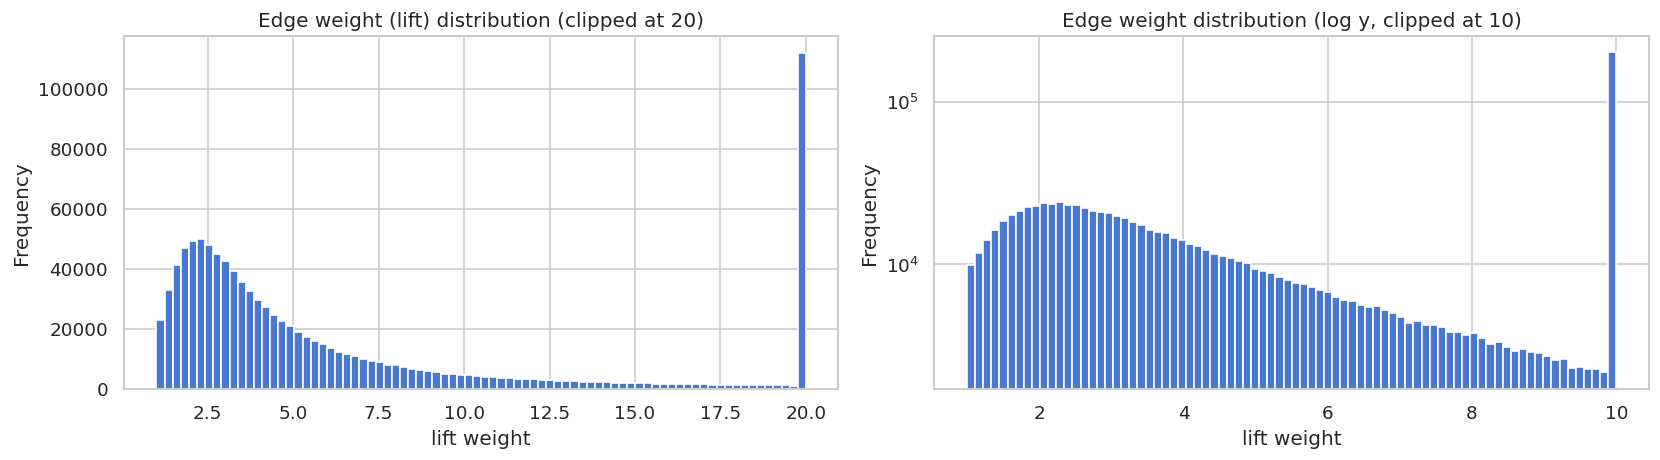

In [14]:
# Edge weight distribution
weights = [d["weight"] for _, _, d in G.edges(data=True)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(weights).clip(upper=20).plot(kind="hist", bins=80, ax=axes[0])
axes[0].set_title("Edge weight (lift) distribution (clipped at 20)")
axes[0].set_xlabel("lift weight")

pd.Series(weights).clip(upper=10).plot(kind="hist", bins=80, log=True, ax=axes[1])
axes[1].set_title("Edge weight distribution (log y, clipped at 10)")
axes[1].set_xlabel("lift weight")
plt.tight_layout()

## 6. Graph visualization

## 6c. Graphviz Visualization (Static High-Quality Layout)

In [24]:
from pyvis.network import Network
import os

# Build lookup tables from preprocessing metadata (graph nodes use product_idx)
idx_to_product_id = {
    str(idx): str(pid)
    for idx, pid in zip(product_meta.index, product_meta["product_id"])
}
idx_to_department = {
    str(idx): dept
    for idx, dept in zip(product_meta.index, product_meta["department"])
}
idx_to_name = {
    str(idx): name
    for idx, name in zip(product_meta.index, product_meta["commodity_desc"])
}

# Weighted in-strength per node (sum of incoming edge weights)
in_strength = {
    n: sum(float(d.get("weight", 1.0)) for _, _, d in G.in_edges(n, data=True))
    for n in G.nodes()
}

# Subgraph: top-10 hubs + their strongest neighbours (keeps it interactive, not overwhelming)
N_HUBS = 10
MIN_LIFT_VIS = 1   # raise this to reduce edge count

hub_nodes = [n for n, _ in sorted(in_strength.items(), key=lambda x: x[1], reverse=True)[:N_HUBS]]
vis_nodes = set(hub_nodes)
vis_edges = []

for hub in hub_nodes:
    neighbours = sorted(
        [(j, G[hub][j]["weight"]) for j in G.successors(hub) if G[hub][j]["weight"] >= MIN_LIFT_VIS],
        key=lambda x: x[1], reverse=True,
    )
    for nb, w in neighbours:
        vis_nodes.add(nb)
        vis_edges.append((hub, nb, w))

net = Network(height="650px", width="100%", directed=True, notebook=True)
net.barnes_hut(gravity=-8000, spring_length=180)

DEPT_COLORS = {
    "GROCERY":      "#3498db",
    "PRODUCE":      "#2ecc71",
    "MEAT-PCKGD":   "#e74c3c",
    "DELI":         "#e67e22",
    "DAIRY":        "#9b59b6",
    "FROZEN FOODS": "#1abc9c",
    "FLORAL":       "#f1c40f",
    "DRUG GM":      "#95a5a6",
}

for node in vis_nodes:
    idx = str(node)
    pid = idx_to_product_id.get(idx, idx)
    name = idx_to_name.get(idx, pid)
    dept = idx_to_department.get(idx, "")
    color = DEPT_COLORS.get(dept, "#bdc3c7")
    size = 35 if node in hub_nodes else 20
    net.add_node(
        node,
        label=name,
        title=pid,
        color=color,
        size=size,
        font={"size": 13, "face": "arial", "strokeWidth": 3, "strokeColor": "#ffffff"},
    )

for u, v, w in vis_edges:
    net.add_edge(u, v, value=w, title=f"lift={w:.2f}", arrows="to")

out_path = os.path.join("..", "outputs", "figures", "graph_vis.html")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
net.write_html(out_path)
print(f"Saved to {out_path}")

# Quick sanity check for color coverage
colored = sum(1 for n in vis_nodes if idx_to_department.get(str(n), "") in DEPT_COLORS)
print(f"Nodes with mapped department colors: {colored}/{len(vis_nodes)}")

Saved to ../outputs/figures/graph_vis.html
Nodes with mapped department colors: 307/330
